# Prepare data

In [4]:
!pip install pydicom
!pip install shap
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up aenvironment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/filtered_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)


# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
print (embeddings)

Updated property [core/project].
      embedding_0  embedding_1  embedding_2  embedding_3  embedding_4  \
0       -1.740258    -0.782546     0.805217    -1.685203    -0.150928   
1       -0.911495    -0.515437     0.619245    -2.373145    -0.171805   
2       -1.034045    -0.783105     0.583782    -1.079196     0.196727   
3       -1.498975    -0.566318     0.506368    -1.586067     0.069659   
4       -0.716697    -0.587135     1.320426    -2.036464    -0.071745   
...           ...          ...          ...          ...          ...   
1112    -1.295518    -0.371794     0.170809    -2.018295     0.624668   
1113    -0.767546    -0.130139     0.142088    -2.607982    -0.953248   
1114    -0.091549    -1.316677     0.362403    -2.207046     0.192631   
1115     0.394565    -0.205986     1.213435    -1.648330     0.394253   
1116    -0.996493    -1.363348     0.844462    -1.462523     0.076252   

      embedding_5  embedding_6  embedding_7  embedding_8  embedding_9  ...  \
0        0.5

# Silhouette score and Elbow method to choose PCA parameters

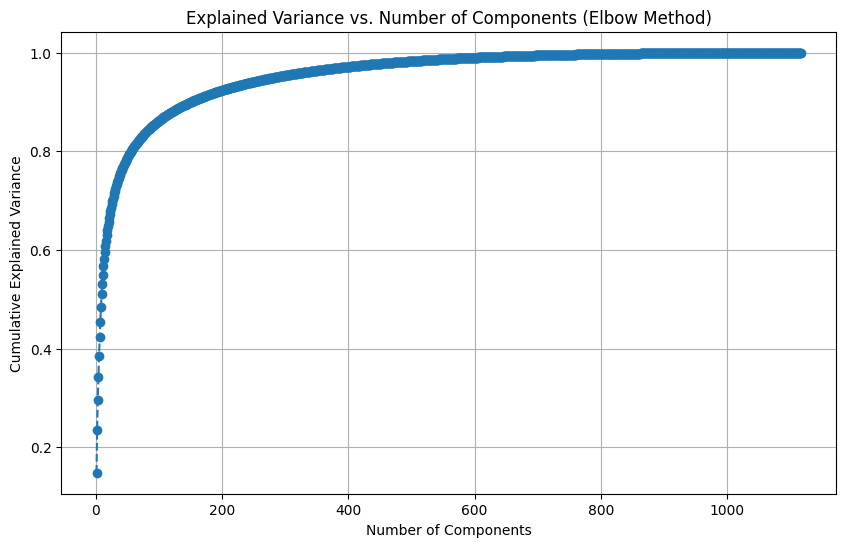

The optimal number of components based on silhouette score is: 62
[[-4.62993837e+00  2.18177171e+00 -3.13937452e+00 ...  1.20503784e-02
  -4.70312074e-01  4.44362058e-01]
 [-3.84081017e+00  1.38279085e+00  1.29619876e+00 ... -1.76922772e+00
   1.09545077e+00 -4.93614073e-01]
 [-5.97690624e+00 -3.53642612e-01 -2.20871918e-01 ... -7.88054227e-01
  -1.02062184e+00  1.44840626e-01]
 ...
 [-3.41695376e+00  3.77096020e+00 -6.04413886e+00 ...  1.30443403e+00
   9.04226697e-01  5.37686374e-01]
 [ 1.40761318e+01 -6.67155879e+00  3.99941670e+00 ...  1.08086455e-01
   7.48754493e-01  1.30503536e-01]
 [-9.28944469e+00  2.48160608e+00 -3.18441926e+00 ...  8.33703046e-01
  -4.35044158e-01 -4.40314989e-01]]
62
1117


In [5]:
# Determine the optimal number of PCA components using the elbow method
pca = PCA()
embeddings_pca = pca.fit_transform(embeddings)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance to use the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Elbow Method)')
plt.grid()
plt.show()

# Using the Silhouette method to determine the optimal number of components
def optimal_number_of_components(data, max_components=10):
    silhouette_scores = []
    for n_components in range(2, max_components + 1):
        pca = PCA(n_components=n_components)
        transformed_data = pca.fit_transform(data)
        kmeans = KMeans(n_clusters=n_components, n_init=10)  # Explicitly set n_init
        kmeans.fit(transformed_data)
        score = silhouette_score(transformed_data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_components + 1), silhouette_scores, marker='o', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs. Number of Components')
    plt.grid()
    plt.show()

    optimal_components = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
    return optimal_components

# Display optimal number of features using silhouette score
optimal_components = 62
print(f'The optimal number of components based on silhouette score is: {optimal_components}')

# Apply PCA with optimal number of components
pca = PCA(n_components=optimal_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

print (embeddings_pca)
print (len(embeddings_pca[0]))
print (len(embeddings_pca))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

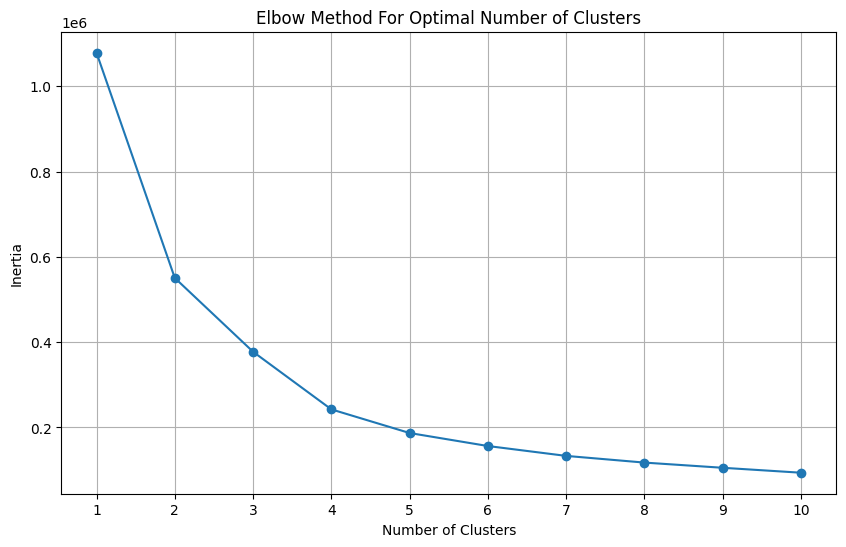

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define a range of possible cluster numbers
cluster_range = range(1, 11)
inertia = []

# Perform K-means clustering for each number of clusters and compute inertia
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_tsne)  # X_tsne is the t-SNE reduced data
    inertia.append(kmeans.inertia_)

# Plot the inertia for each number of clusters
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()


# Perform PCA (62 components) and t-sne (2D)

In [7]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming you have already loaded and processed the data as in your provided code
# Step 1: Apply PCA to reduce the embedding dimensions to 62 components
chosen_components = 62
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Step 2: Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Step 3: Apply t-SNE to reduce dimensions from 62 to 2 components
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(embeddings_pca)

# Add t-SNE components to the dataframe for visualization and clustering
df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

# Find K-nearest neighbour from the raw data for a randomly chosen patient and show 20 closest patient data

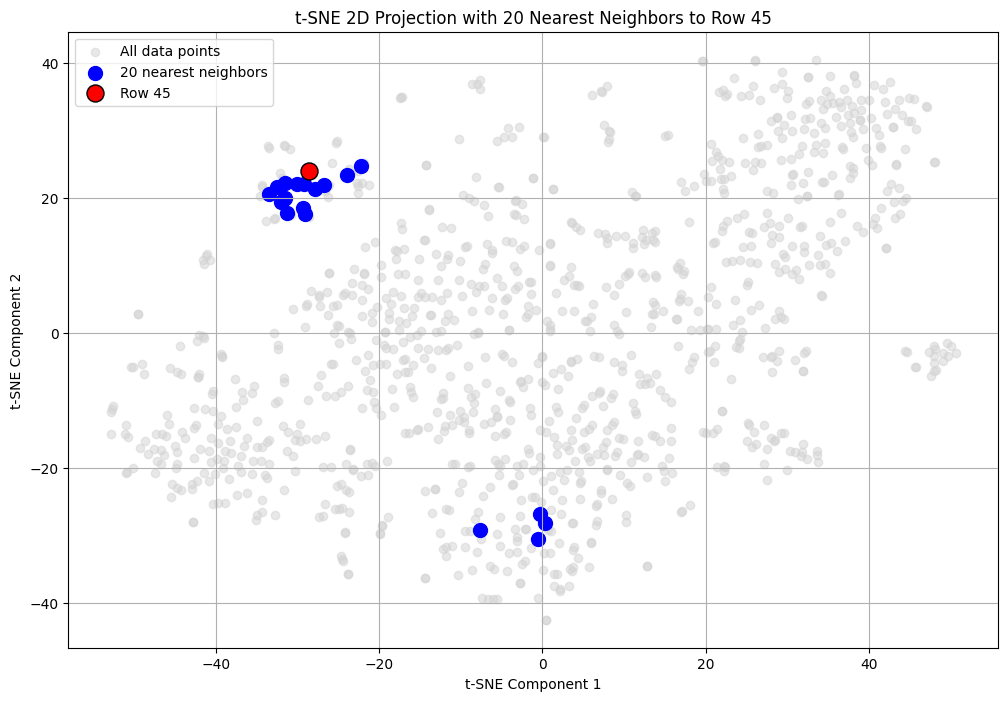

In [8]:
# Step 4: Choose a specific row and find its 50 nearest neighbors
row_index = 45  # Example row index; change as needed
n_neighbors = 20

# Extract the data from the chosen row
query_row = embeddings_pca[row_index].reshape(1, -1)

# Initialize the NearestNeighbors model
nn_model = NearestNeighbors(n_neighbors=n_neighbors+1, algorithm='auto', metric='euclidean')
nn_model.fit(embeddings_pca)

# Find the nearest neighbors
distances, indices = nn_model.kneighbors(query_row)

# Exclude the first neighbor (the row itself)
nearest_neighbors_indices = indices.flatten()[1:]

# Step 5: Visualize the t-SNE results highlighting the chosen row and its neighbors
plt.figure(figsize=(12, 8))

# Plot all points
plt.scatter(df['tsne_1'], df['tsne_2'], c='lightgray', alpha=0.5, label='All data points')

# Highlight the 50 nearest neighbors
plt.scatter(df.iloc[nearest_neighbors_indices]['tsne_1'], df.iloc[nearest_neighbors_indices]['tsne_2'], c='blue', label=f'{n_neighbors} nearest neighbors', s=100)

# Highlight the chosen row
plt.scatter(df.iloc[row_index]['tsne_1'], df.iloc[row_index]['tsne_2'], c='red', label=f'Row {row_index}', edgecolors='black', s=150)

# Add labels and legend
plt.title(f't-SNE 2D Projection with {n_neighbors} Nearest Neighbors to Row {row_index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True)
plt.show()


# SHAP analysis to find the optimal PEEP level for a randomly selected patient using XG boost

Randomly Selected Patient's PEEP Level: 8.0
Randomly Selected Patient's Mortality (1=Death, 0=Survival): 0


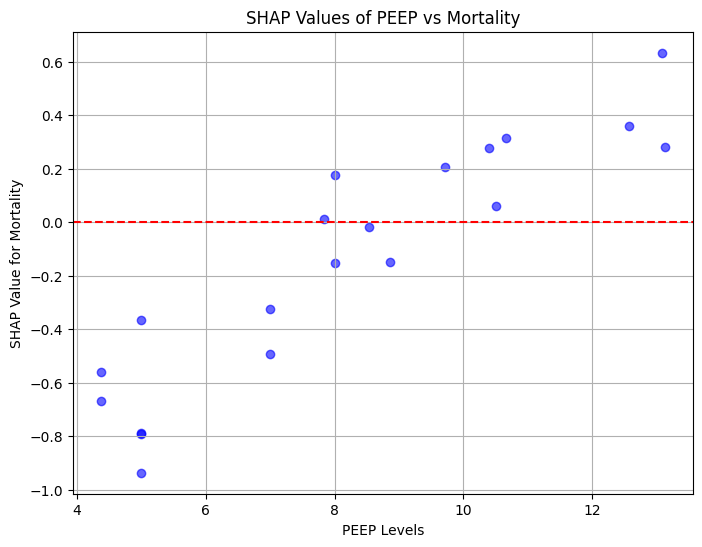

In [20]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import shap
import random
import matplotlib.pyplot as plt

# Step 1: Data Preparation
# Assuming df contains the necessary columns, including embeddings and avg_peep
X = np.hstack((embeddings, df[['avg_peep']].values))  # Combine CXR embeddings with PEEP as input
y = df['icu_mort']  # Mortality as the target variable

# Define feature names: one for each embedding feature and one for 'avg_peep'
feature_names = [f'embedding_{i+1}' for i in range(embeddings.shape[1])] + ['avg_peep']

# Step 2: Train XGBoost Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Step 3: Select a Random Patient Row and Find the 20 Nearest Neighbors
random_row_index = random.randint(0, X_test.shape[0] - 1)
random_patient_row = X_test[random_row_index].reshape(1, -1)

# Output the actual PEEP and mortality for the randomly selected patient
selected_patient_peep = random_patient_row[0, -1]  # The last column is avg_peep
selected_patient_mortality = y_test.iloc[random_row_index]  # Corresponding mortality

print(f"Randomly Selected Patient's PEEP Level: {selected_patient_peep}")
print(f"Randomly Selected Patient's Mortality (1=Death, 0=Survival): {selected_patient_mortality}")

# Use NearestNeighbors to find the closest 20 points
nn_model = NearestNeighbors(n_neighbors=21, algorithm='auto', metric='euclidean')
nn_model.fit(X_train)
distances, indices = nn_model.kneighbors(random_patient_row)

# Exclude the first neighbor (which is the point itself)
nearest_neighbors_indices = indices.flatten()[1:]
nearest_neighbors_data = X_train[nearest_neighbors_indices]

# Step 4: SHAP Analysis
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(nearest_neighbors_data)

# Extract the SHAP values for 'avg_peep'
peep_index = feature_names.index('avg_peep')
peep_shap_values = shap_values[:, peep_index]

# Extract the 'avg_peep' values for the nearest neighbors
peep_values = nearest_neighbors_data[:, peep_index]

# Step 5: Plot SHAP value against avg_peep values
plt.figure(figsize=(8, 6))
plt.scatter(peep_values, peep_shap_values, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('PEEP Levels')
plt.ylabel('SHAP Value for Mortality')
plt.title('SHAP Values of PEEP vs Mortality')
plt.grid(True)
plt.show()
